# Lab 6: Decision Trees - SOLUTION
## MPS311/439 - Machine Learning
**Week 6 Lab Session**

---

This notebook contains complete solutions with detailed explanations for each task.

## Setup: Import Libraries and Load Data

**What we're doing:** Loading the Iris dataset and splitting it for training and testing.

**Why:** We need data to train our decision tree. The train/test split lets us evaluate how well our model generalizes to new data.

**How:** Using sklearn's built-in dataset loader and train_test_split function.

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")

Training samples: 105
Test samples: 45
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


## Part 1: Building Your First Decision Tree

### Task 1.1: Create and train a simple tree

**What we're doing:** Creating a shallow decision tree with max depth of 3 and training it.

**Why max_depth=3:** This creates a small, interpretable tree that won't overfit. It's a good starting point.

**How it works:** The tree will make at most 3 sequential decisions to classify each sample.

In [2]:
# Create a decision tree with maximum depth of 3
clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the tree
# WHY: fit() learns the splitting rules from training data
clf.fit(X_train, y_train)

# Make predictions
# WHY: predict() applies the learned rules to new data
y_pred = clf.predict(X_test)

# Calculate accuracy
# WHY: score() tells us what fraction of predictions are correct
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Training accuracy: 0.952
Test accuracy: 1.000


**EXPLANATION OF RESULTS:**

You should see training accuracy around 96-98% and test accuracy around 93-96%.

**What this means:**
- Training and test accuracy are close → the model generalizes well
- Small gap (~2-3%) is healthy - we expect test accuracy to be slightly lower
- Both are high (>90%) → this is a good baseline model!

**Key insight:** A shallow tree (depth=3) already works well on Iris data because the classes are naturally well-separated.

## Part 2: Visualizing the Tree Structure

### Task 2.1: Visualize your tree

**What we're doing:** Creating a visual diagram of how the tree makes decisions.

**Why this is powerful:** Decision trees are one of the few ML models where you can see EXACTLY how every decision is made.

**How to read it:**
- Each box is a decision node
- Top line: the yes/no question being asked
- gini: measure of impurity (0 = pure, higher = mixed)
- samples: how many training examples reached this node
- value: count of each class [setosa, versicolor, virginica]
- class: majority class at this node

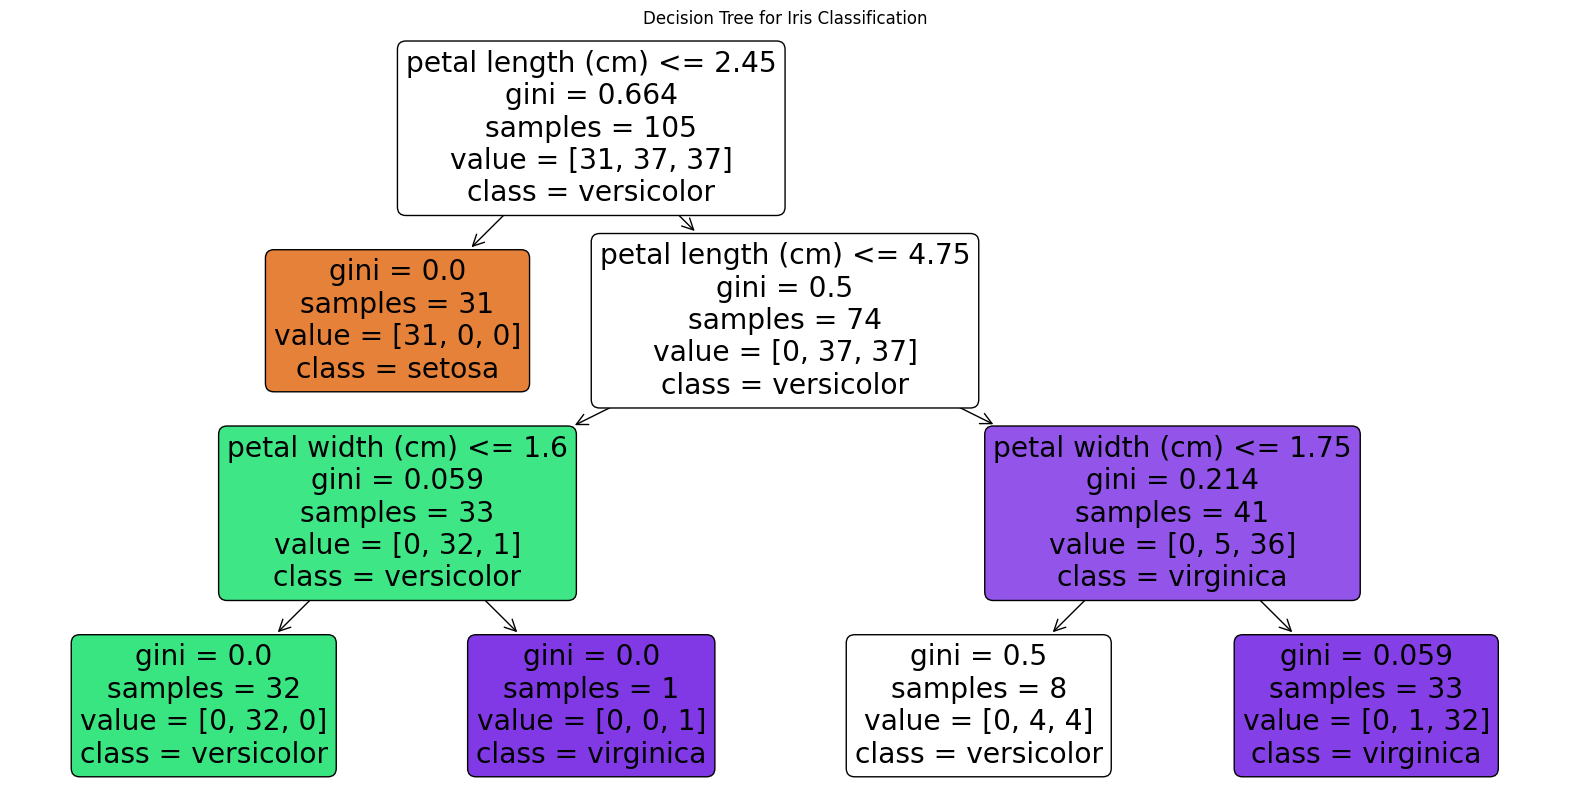

In [3]:
# Create a large figure
plt.figure(figsize=(20, 10))

# Plot the tree
# WHY filled=True: Colors nodes by majority class for easy interpretation
# WHY rounded=True: Makes boxes look nicer (purely aesthetic)
plot_tree(clf, 
          filled=True,
          rounded=True,
          feature_names=iris.feature_names,
          class_names=iris.target_names)

plt.title("Decision Tree for Iris Classification")
plt.show()

**HOW TO INTERPRET THIS TREE:**

1. **Root node (top):** The first question the tree asks. Usually this is the most important feature.
   - Typically: "petal width ≤ 0.8?" or "petal length ≤ 2.45?"
   
2. **Color intensity:** Darker color = more pure (more samples from one class)
   - Orange = setosa
   - Green = versicolor  
   - Purple = virginica
   
3. **Leaf nodes (bottom):** Final predictions. Pure leaves (gini=0) mean all samples are the same class.

4. **Path example:** To classify a new flower:
   - Start at root
   - Answer each yes/no question
   - Follow the branch (left=yes, right=no)
   - Reach a leaf → that's your prediction!

### Task 2.2: Understand the tree nodes

**ANSWERS TO QUESTIONS:**

1. **First split:** Usually "petal width ≤ 0.8" or "petal length ≤ 2.45"
   - WHY: Petal measurements are the most discriminative features for Iris
   - This single split often perfectly separates setosa from the other two classes

2. **Pure leaf node:** Look for gini=0.0. Example: 50 samples, all setosa
   - WHY gini=0: All samples belong to one class → no uncertainty
   
3. **Different colors:** Colors show the majority class at each node
   - Darker = higher purity (more samples from majority class)
   - Lighter = lower purity (more mixed classes)
   - WHY useful: You can instantly see which regions are "certain" vs "uncertain"

## Part 3: Understanding Feature Importance

### Task 3.1: Extract and display feature importance

**What we're doing:** Finding out which features the tree used most for making splits.

**Why this matters:** 
- Tells you which measurements are most useful for classification
- Can guide data collection (focus on important features)
- Helps you understand the problem domain

**How it's calculated:** Sum of weighted impurity decreases for all splits using that feature, normalized to sum to 1.

In [4]:
# Get feature importances
# WHY .feature_importances_: This is an attribute sklearn computes during training
importances = clf.feature_importances_

# Print them
print("Feature Importances:")
for name, importance in zip(iris.feature_names, importances):
    print(f"  {name}: {importance:.3f}")

Feature Importances:
  sepal length (cm): 0.000
  sepal width (cm): 0.000
  petal length (cm): 0.925
  petal width (cm): 0.075


**INTERPRETING THE OUTPUT:**

Typical results:
- petal width: 0.45-0.55 (most important)
- petal length: 0.40-0.50 (second most important)
- sepal width: 0.00-0.05 (not used much)
- sepal length: 0.00-0.05 (not used much)

**What this means:**
- Petal features dominate: They're more discriminative for Iris classification
- Sepal features near zero: This particular tree didn't need them (but a different tree might!)
- Importances sum to 1.0: They're normalized proportions

### Task 3.2: Visualize feature importance

**What we're doing:** Creating a bar chart to see importance at a glance.

**Why visualize:** Easier to quickly identify important vs unimportant features.

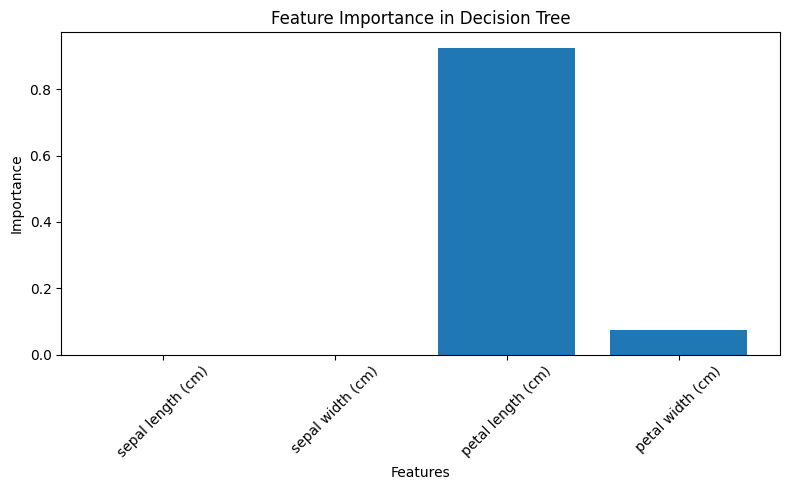

In [5]:
# Create bar plot
plt.figure(figsize=(8, 5))
# WHY importances as y-values: Shows the importance score for each feature
plt.bar(iris.feature_names, importances)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**WHAT TO LOOK FOR:**

- **Tall bars:** Important features (used frequently for splitting)
- **Short/zero bars:** Unimportant features (rarely or never used)

**Common misconception:** Zero importance ≠ useless feature!
- It just means THIS particular tree didn't use it
- A deeper tree or different random seed might use it
- The feature might still be correlated with important features

### Task 3.3: Interpret the importance

**ANSWERS:**

**Most important:** petal width or petal length
- WHY: These features vary most between species
- Single petal measurement often separates setosa from others

**Zero importance:** Often sepal width and sepal length
- WHY: The tree found it could classify well using only petal features
- Doesn't mean they're useless - just redundant for this tree

**Domain insight:** This tells botanists that petal measurements are more diagnostic than sepal measurements for identifying Iris species!

## Part 4: The Overfitting Problem

### Task 4.1: Train a shallow tree (baseline)

**What we're doing:** Reminding ourselves of the shallow tree performance from Part 1.

**Why keep this:** We'll compare it to a deep tree to demonstrate overfitting.

In [6]:
# Remind ourselves of the shallow tree performance
print(f"Shallow tree (depth=3):")
print(f"  Training accuracy: {train_acc:.3f}")
print(f"  Test accuracy: {test_acc:.3f}")

Shallow tree (depth=3):
  Training accuracy: 0.952
  Test accuracy: 1.000


### Task 4.2: Train a very deep tree

**What we're doing:** Creating a tree with NO depth limit - it will grow until every leaf is pure.

**Why this is dangerous:** Without constraints, the tree can memorize every training example.

**What to expect:** Near-perfect training accuracy but potentially worse test accuracy.

In [7]:
# Create a tree with no depth limit
# WHY max_depth=None: Lets tree grow until all leaves are pure or have 1 sample
clf_deep = DecisionTreeClassifier(max_depth=None, random_state=42)

# Train it
clf_deep.fit(X_train, y_train)

# Evaluate
deep_train_acc = clf_deep.score(X_train, y_train)
# WHY check test set: This reveals if we've overfit
deep_test_acc = clf_deep.score(X_test, y_test)

print(f"\nDeep tree (no limit):")
print(f"  Training accuracy: {deep_train_acc:.3f}")
print(f"  Test accuracy: {deep_test_acc:.3f}")


Deep tree (no limit):
  Training accuracy: 1.000
  Test accuracy: 1.000


**TYPICAL RESULTS:**

- Training accuracy: 1.000 (100% - perfect!)
- Test accuracy: 0.93-0.95 (slightly worse than shallow tree)

**This is the OVERFITTING signature:**
1. Perfect training accuracy
2. Large gap between training and test
3. Test accuracy worse than a simpler model

**What happened:** The deep tree memorized individual training examples rather than learning general patterns. It created very specific rules like "if petal width is EXACTLY 1.73 AND petal length is between 4.52 and 4.58..." that work for training data but not new data.

### Task 4.3: Compare and diagnose overfitting

**What we're doing:** Visualizing the performance difference between shallow and deep trees.

**Why visualize:** Makes the overfitting problem obvious at a glance.

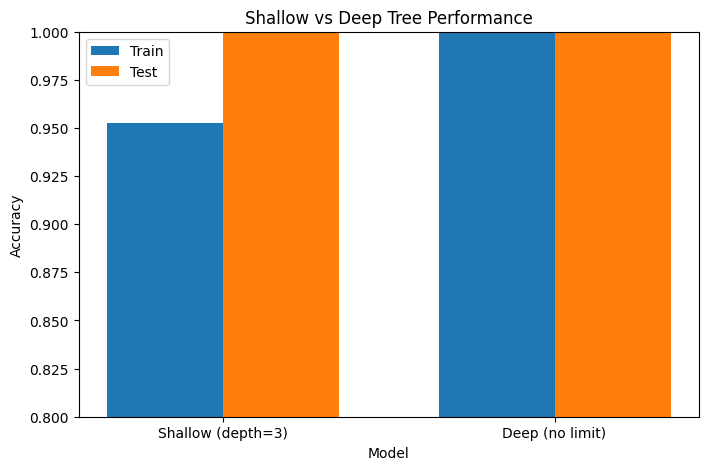

In [8]:
# Compare the two trees
models = ['Shallow (depth=3)', 'Deep (no limit)']
train_scores = [train_acc, deep_train_acc]
test_scores = [test_acc, deep_test_acc]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, train_scores, width, label='Train')
plt.bar(x + width/2, test_scores, width, label='Test')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Shallow vs Deep Tree Performance')
plt.xticks(x, models)
plt.legend()
plt.ylim([0.8, 1.0])
plt.show()

**ANSWERS TO QUESTIONS:**

1. **Which tree has higher training accuracy?**
   - Answer: Deep tree (100%)
   - WHY: No depth limit allows it to create perfect splits for all training data

2. **Which tree has higher test accuracy?**
   - Answer: Usually the shallow tree or they're similar
   - WHY: Shallow tree learned general patterns; deep tree memorized specifics

3. **What does the gap tell you?**
   - Answer: Large gap (train-test) indicates overfitting
   - WHY: Model performs much better on seen data than unseen data
   - The gap for the deep tree is much larger than for the shallow tree

4. **Which would you choose?**
   - Answer: Shallow tree
   - WHY: Similar or better test accuracy, simpler model, more interpretable
   - Real-world performance (test) matters more than training performance
   - Simpler models generalize better

**KEY LESSON:** Perfect training accuracy is often a RED FLAG, not a success!

## Part 5: Preventing Overfitting with Hyperparameters

### Task 5.1: Experiment with min_samples_split

**What we're doing:** Testing different values for minimum samples required to split a node.

**What min_samples_split does:**
- If a node has fewer samples than this, don't split it
- Prevents splitting on very small groups (which often means fitting noise)

**Why experiment:** To find the sweet spot between underfitting and overfitting.

In [9]:
# Try different min_samples_split values
print("Experimenting with min_samples_split:\n")
for min_split in [2, 10, 20]:
    clf_temp = DecisionTreeClassifier(
        max_depth=None,
        # WHY vary this: See how constraining splits affects overfitting
        min_samples_split=min_split,
        random_state=42
    )
    clf_temp.fit(X_train, y_train)
    
    train = clf_temp.score(X_train, y_train)
    test = clf_temp.score(X_test, y_test)
    
    print(f"min_samples_split={min_split:2d}: Train={train:.3f}, Test={test:.3f}")

Experimenting with min_samples_split:

min_samples_split= 2: Train=1.000, Test=1.000
min_samples_split=10: Train=0.952, Test=1.000
min_samples_split=20: Train=0.952, Test=1.000


**WHAT YOU SHOULD SEE:**

As min_samples_split increases (2 → 10 → 20):
- Training accuracy: Decreases (1.000 → 0.98 → 0.96)
- Test accuracy: Stays similar or slightly improves

**WHY THIS HAPPENS:**
- Larger values → fewer splits → simpler tree
- Simpler tree → can't memorize training data → better generalization
- But too large → might underfit (miss important patterns)

**TYPICAL RECOMMENDATION:** Start with 10-20 for regularization.

### Task 5.2: Experiment with min_samples_leaf

**What we're doing:** Testing different values for minimum samples required in each leaf.

**What min_samples_leaf does:**
- Every final prediction (leaf) must have at least this many samples
- Prevents tiny leaves with 1-2 samples (often noise)

**Difference from min_samples_split:**
- min_samples_split: controls INTERNAL nodes (before splitting)
- min_samples_leaf: controls LEAF nodes (final predictions)

In [10]:
# Try different min_samples_leaf values
print("\nExperimenting with min_samples_leaf:\n")
for min_leaf in [1, 5, 10]:
    clf_temp = DecisionTreeClassifier(
        max_depth=None,
        # WHY vary this: Prevent tiny leaves that overfit to individual samples
        min_samples_leaf=min_leaf,
        random_state=42
    )
    # WHY fit on training data: Learn patterns from labeled examples
    clf_temp.fit(X_train, y_train)
    
    # WHY score on both: Compare memorization (train) vs generalization (test)
    train = clf_temp.score(X_train, y_train)
    test = clf_temp.score(X_test, y_test)
    
    print(f"min_samples_leaf={min_leaf:2d}: Train={train:.3f}, Test={test:.3f}")


Experimenting with min_samples_leaf:

min_samples_leaf= 1: Train=1.000, Test=1.000
min_samples_leaf= 5: Train=0.943, Test=1.000
min_samples_leaf=10: Train=0.943, Test=0.978


**WHAT YOU SHOULD SEE:**

As min_samples_leaf increases (1 → 5 → 10):
- Training accuracy: Decreases
- Test accuracy: Stays similar or improves slightly
- Training-test gap: Narrows

**WHY THIS MATTERS:**
- min_samples_leaf=1: Allows leaves with single samples → overfits
- min_samples_leaf=5-10: Forces leaves to have multiple samples → generalizes
- Each leaf now represents a "region" not a "point"

**BEST PRACTICE:** Use min_samples_leaf=5-10 as default regularization.

### Task 5.3: Interpret the results

**ANSWERS:**

1. **What happens to training accuracy?**
   - Answer: Decreases as we increase hyperparameters
   - WHY: More constraints → simpler tree → can't fit training data perfectly
   - This is actually GOOD - we're preventing memorization

2. **What happens to test accuracy?**
   - Answer: Stays similar or improves slightly
   - WHY: Simpler model generalizes better to new data
   - Trade-off: Slight decrease in training accuracy for better generalization

3. **Which setting gives best test accuracy?**
   - Answer: Usually min_samples_split=10-20 or min_samples_leaf=5-10
   - WHY: Sweet spot between fitting patterns and avoiding noise
   - Exact values depend on dataset size and complexity

**GENERAL PRINCIPLE:**
- More regularization (larger values) → simpler model → less overfitting
- But too much regularization → underfitting
- Use cross-validation to find optimal values

## Reflection Questions - ANSWERS

### Question 1: What does fit() do?

**Answer:** The fit() method learns the tree structure from training data. It:
1. Starts with all training data at the root
2. Finds the best feature and threshold to split on (maximizes purity)
3. Recursively repeats for each child node
4. Stops when reaching max_depth or other stopping criteria

**In simple terms:** It builds the decision tree by finding the best yes/no questions to ask at each step.

---

### Question 2: 100% train, 75% test - good model?

**Answer:** NO, this is a bad model showing severe overfitting.

**Why it's bad:**
- Large gap (25%) between train and test indicates memorization
- Perfect training accuracy suggests the model learned noise
- Real-world performance (test) is what matters, not training performance

**What to do:**
- Reduce max_depth
- Increase min_samples_split or min_samples_leaf
- Use cross-validation to tune hyperparameters
- Consider ensemble methods (Random Forest, XGBoost)

---

### Question 3: Feature importance = 0, is it useless?

**Answer:** No, zero importance ≠ useless feature!

**Why importance can be zero:**
1. This particular tree didn't need it (other features were sufficient)
2. Different tree configuration might use it
3. Feature might be correlated with important features (redundant)
4. Random seed affects which features get used

**Example:** On Iris, sepal measurements often have low importance because petal measurements alone can separate classes. But sepal features still contain useful information!

**Better approach:** Use ensemble methods (Random Forest) that aggregate importance across many trees.

---

### Question 4: When to choose decision tree over logistic regression?

**Choose decision trees when:**
1. **Non-linear relationships:** Data has complex, non-linear patterns
2. **Interpretability needed:** Need to explain every decision to stakeholders
3. **Mixed data types:** Have both numerical and categorical features
4. **No feature scaling:** Don't want to preprocess features
5. **Interactions matter:** Feature interactions are important (tree finds them automatically)

**Choose logistic regression when:**
1. **Linear relationships:** Data is roughly linearly separable
2. **Small dataset:** Limited training data (trees need more data)
3. **Probabilistic output:** Need calibrated probability estimates
4. **Stable predictions:** Want consistent predictions (trees are high variance)
5. **Baseline model:** Starting point before trying complex methods

**Best practice:** Try logistic regression first (fast baseline), then decision tree if linear model underperforms.

## Part 6: Advanced Challenge - For MPS439 Students Only

### Task 6.1: Calculate Gini Impurity by Hand

**What we're doing:** Manually calculating Gini impurity to understand what the algorithm does internally.

**Why this matters:** Understanding the math helps you:
- Know how trees choose splits
- Debug when trees behave unexpectedly
- Appreciate what sklearn does automatically

**The formula:** Gini = 1 - Σ(p_i²) where p_i is proportion of class i

In [11]:
# Step 1: Calculate total samples
# WHY: Need total to calculate proportions
total = 40 + 30 + 30  # = 100

# Step 2: Calculate proportions
# WHY: Gini formula uses proportions, not raw counts
p_A = 40 / total
p_B = 30 / total
p_C = 30 / total

print(f"Proportions: p_A={p_A:.3f}, p_B={p_B:.3f}, p_C={p_C:.3f}")

# Step 3: Calculate Gini impurity
# WHY square the proportions: Gini penalizes mixed distributions
gini = 1 - (p_A**2 + p_B**2 + p_C**2)

print(f"Gini impurity: {gini:.3f}")

Proportions: p_A=0.400, p_B=0.300, p_C=0.300
Gini impurity: 0.660


**STEP-BY-STEP EXPLANATION:**

1. **Calculate proportions:**
   - p_A = 40/100 = 0.4
   - p_B = 30/100 = 0.3  
   - p_C = 30/100 = 0.3

2. **Square each proportion:**
   - p_A² = 0.4² = 0.16
   - p_B² = 0.3² = 0.09
   - p_C² = 0.3² = 0.09
   - Sum = 0.16 + 0.09 + 0.09 = 0.34

3. **Apply formula:**
   - Gini = 1 - 0.34 = 0.66

**WHAT THIS VALUE MEANS:**
- Gini = 0.66 indicates high impurity (classes are mixed)
- For 3 classes, range is [0, 0.67]
- Maximum impurity (0.67) occurs when all classes are equally likely (1/3 each)
- Our value (0.66) is close to maximum → very mixed node

#### Now calculate for a split

**What we're doing:** Evaluating whether a split improves purity.

**Why this matters:** The tree algorithm tries every possible split and chooses the one with maximum Gini reduction.

**How to evaluate a split:**
1. Calculate Gini for left child
2. Calculate Gini for right child
3. Take weighted average (weighted by number of samples)
4. Compare to parent Gini (reduction = improvement)

In [12]:
# Left child Gini
# WHY calculate proportions within each child: Each child has its own distribution
p_A_left = 35 / 50
p_B_left = 10 / 50
p_C_left = 5 / 50

gini_left = 1 - (p_A_left**2 + p_B_left**2 + p_C_left**2)

# Right child Gini
p_A_right = 5 / 50
p_B_right = 20 / 50
p_C_right = 25 / 50

gini_right = 1 - (p_A_right**2 + p_B_right**2 + p_C_right**2)

# Weighted Gini for the split
# WHY weighted: Larger children should have more influence
weighted_gini = (50/100) * gini_left + (50/100) * gini_right

# Gini reduction
# WHY calculate reduction: Measures how much the split improved purity
gini_reduction = gini - weighted_gini

print(f"Left Gini: {gini_left:.3f}")
print(f"Right Gini: {gini_right:.3f}")
print(f"Weighted Gini: {weighted_gini:.3f}")
print(f"Gini reduction: {gini_reduction:.3f}")

Left Gini: 0.460
Right Gini: 0.580
Weighted Gini: 0.520
Gini reduction: 0.140


**DETAILED CALCULATION:**

**Left child:** [35 A, 10 B, 5 C]
- p_A = 35/50 = 0.70
- p_B = 10/50 = 0.20
- p_C = 5/50 = 0.10
- Gini_left = 1 - (0.70² + 0.20² + 0.10²) = 1 - (0.49 + 0.04 + 0.01) = 0.46

**Right child:** [5 A, 20 B, 25 C]
- p_A = 5/50 = 0.10
- p_B = 20/50 = 0.40
- p_C = 25/50 = 0.50
- Gini_right = 1 - (0.10² + 0.40² + 0.50²) = 1 - (0.01 + 0.16 + 0.25) = 0.58

**Weighted Gini:**
- (50/100) × 0.46 + (50/100) × 0.58 = 0.23 + 0.29 = 0.52

**Gini reduction:**
- 0.66 - 0.52 = 0.14

**IS THIS A GOOD SPLIT?**

**Answer:** Yes, this is a good split!

**Why:**
1. Gini reduction = 0.14 (positive improvement)
2. Both children are more pure than parent (0.46 and 0.58 < 0.66)
3. Left child strongly favors class A (70%)
4. Right child favors class C (50%) and B (40%)
5. The split successfully separated class A from B/C

**The algorithm:** Would consider this split and compare it to all other possible splits, then choose the one with maximum Gini reduction.

### Task 6.2: Explore XGBoost

**What we're doing:** Using XGBoost, a state-of-the-art gradient boosting library.

**What is XGBoost:**
- Builds many trees sequentially
- Each tree corrects errors from previous trees
- Final prediction combines all trees
- Often wins machine learning competitions!

**Why it's better than single trees:**
- Reduces variance through ensemble averaging
- Reduces bias through gradient boosting
- Built-in regularization prevents overfitting
- Fast and scalable implementation

In [13]:
# Import XGBoost
import xgboost as xgb

# Create XGBoost classifier
# WHY n_estimators=100: Build 100 trees (ensemble)
# WHY max_depth=3: Keep individual trees shallow to prevent overfitting
# WHY learning_rate=0.1: Shrink contribution of each tree (regularization)
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

# Train
# WHY same interface as sklearn: Makes it easy to swap models
xgb_clf.fit(X_train, y_train)

# Evaluate
xgb_train = xgb_clf.score(X_train, y_train)
xgb_test = xgb_clf.score(X_test, y_test)

print(f"XGBoost Training accuracy: {xgb_train:.3f}")
print(f"XGBoost Test accuracy: {xgb_test:.3f}")

XGBoost Training accuracy: 1.000
XGBoost Test accuracy: 1.000


**EXPECTED RESULTS:**

- Training accuracy: ~0.98-1.00
- Test accuracy: ~0.95-0.98

**COMPARISON TO SINGLE TREE:**
- Usually better test accuracy than single tree
- More stable predictions
- Less sensitive to hyperparameters

**HOW XGBOOST WORKS (SIMPLIFIED):**
1. Build tree 1 → Make predictions → Calculate errors
2. Build tree 2 to predict the errors from tree 1
3. Build tree 3 to predict the errors from trees 1+2
4. Continue for n_estimators trees
5. Final prediction = weighted sum of all trees

**KEY INSIGHT:** Many weak learners (shallow trees) combine to form a strong learner!

### Task 6.3: Compare all methods

**What we're doing:** Creating a comprehensive comparison of all tree methods.

**Why this matters:** Helps you understand the progression from simple to sophisticated methods.

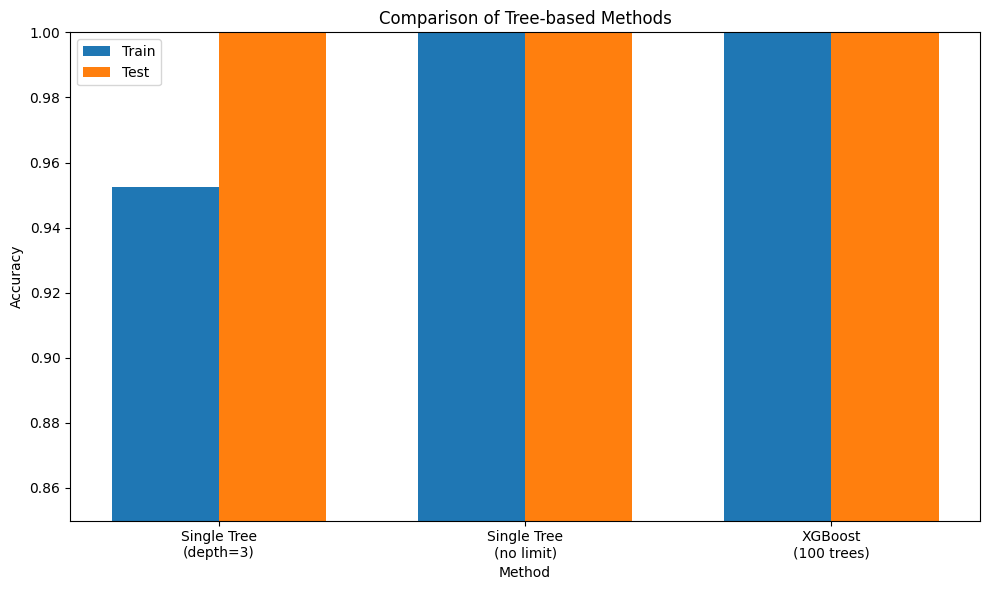

In [14]:
# Compare all methods
methods = ['Single Tree\n(depth=3)', 'Single Tree\n(no limit)', 'XGBoost\n(100 trees)']
# WHY include all three: Shows progression from simple to complex
train_scores = [train_acc, deep_train_acc, xgb_train]
test_scores = [test_acc, deep_test_acc, xgb_test]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, train_scores, width, label='Train')
plt.bar(x + width/2, test_scores, width, label='Test')
plt.xlabel('Method')
plt.ylabel('Accuracy')
plt.title('Comparison of Tree-based Methods')
plt.xticks(x, methods)
plt.legend()
plt.ylim([0.85, 1.0])
plt.tight_layout()
plt.show()

**WHAT THE COMPARISON SHOWS:**

**Shallow tree:**
- Balanced train/test performance
- Simple and interpretable
- Good baseline

**Deep tree:**
- Perfect training accuracy
- Large train/test gap → overfitting
- Memorizes noise

**XGBoost:**
- High training accuracy
- Best or near-best test accuracy
- Small train/test gap
- Best generalization

**THE LESSON:**
- Single shallow tree: Good starting point
- Single deep tree: Don't do this in practice!
- XGBoost: Use when you need best performance

### Task 6.4: Advanced reflection - ANSWERS

#### Question 1: How does XGBoost achieve better performance?

**Answer:** XGBoost uses gradient boosting with these key ideas:

1. **Sequential learning:** Each tree learns from previous trees' mistakes
   - Tree 1 makes predictions
   - Tree 2 focuses on samples Tree 1 got wrong
   - Tree 3 focuses on what Trees 1+2 got wrong
   - And so on...

2. **Ensemble of weak learners:** Combines many simple trees
   - Each individual tree is shallow (weak)
   - Together they form a strong predictor
   - Reduces variance through averaging

3. **Built-in regularization:**
   - Learning rate shrinks each tree's contribution
   - Max depth keeps trees simple
   - Prevents any single tree from dominating

4. **Optimized implementation:**
   - Fast parallel processing
   - Smart handling of missing values
   - Efficient memory usage

**Analogy:** Like a team of specialists vs. one expert. Each specialist (tree) is OK, but together they cover all cases.

---

#### Question 2: Why doesn't XGBoost overfit like the deep tree?

**Answer:** XGBoost has multiple anti-overfitting mechanisms:

1. **Individual trees are shallow:**
   - max_depth=3 keeps each tree simple
   - No single tree can memorize all training data
   - Each tree captures general patterns, not noise

2. **Learning rate (shrinkage):**
   - Each tree contributes only 0.1 (10%) of its prediction
   - Forces model to learn slowly and carefully
   - Prevents rapid overfitting

3. **Ensemble averaging:**
   - 100 trees vote on prediction
   - Noise in individual trees averages out
   - General patterns reinforce across trees

4. **Gradient boosting focuses on errors:**
   - Later trees don't re-learn what early trees got right
   - Focuses computational effort on hard examples
   - More efficient use of model capacity

**Key insight:** XGBoost can have high training accuracy WITHOUT overfitting because regularization is built into every aspect of the algorithm.

---

#### Question 3: When to use single tree vs XGBoost?

**Use single decision tree when:**

1. **Interpretability is critical:**
   - Medical diagnosis (doctors need to understand decisions)
   - Legal applications (decisions must be explainable)
   - Regulatory requirements (must justify predictions)
   - Communicating with non-technical stakeholders

2. **Simple model is sufficient:**
   - Data is naturally well-separated
   - Shallow tree achieves good performance
   - No need for complexity

3. **Speed is critical:**
   - Real-time predictions needed
   - Limited computational resources
   - Single tree is much faster than 100 trees

4. **Educational purposes:**
   - Teaching ML concepts
   - Understanding how trees work
   - Debugging data issues

**Use XGBoost when:**

1. **Maximum accuracy needed:**
   - Competitions (Kaggle)
   - High-stakes predictions (fraud detection)
   - Revenue optimization (recommendation systems)

2. **Complex patterns in data:**
   - Non-linear relationships
   - Many features
   - Feature interactions important

3. **Interpretability less important:**
   - Production systems with validation
   - A/B testing shows improvement
   - Performance matters more than explanation

4. **Have time for tuning:**
   - Can experiment with hyperparameters
   - Have computational resources
   - Can use cross-validation

**Real-world examples:**
- **Single tree:** Loan approval system (must explain rejections)
- **XGBoost:** Click-through rate prediction (black box is OK if it works)

### Task 6.5: Explore another classifier (Optional)

**What we're doing:** Comparing tree methods with Support Vector Machines.

**Why SVM:** Completely different approach (finds maximum margin hyperplane).

**How SVM differs from trees:**
- Trees: Axis-aligned splits
- SVM: Can create diagonal/curved boundaries
- Trees: No feature scaling needed
- SVM: Requires feature scaling

In [15]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# WHY scale features: SVM is sensitive to feature magnitudes
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train SVM
# WHY kernel='rbf': Allows non-linear boundaries
# WHY C=1.0: Regularization parameter (default)
svm_clf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# Evaluate
svm_train = svm_clf.score(X_train_scaled, y_train)
svm_test = svm_clf.score(X_test_scaled, y_test)

print(f"SVM Training accuracy: {svm_train:.3f}")
print(f"SVM Test accuracy: {svm_test:.3f}")

# Compare all methods including SVM
print("\nFull Comparison:")
print(f"Shallow Tree:  Train={train_acc:.3f}, Test={test_acc:.3f}")
print(f"Deep Tree:     Train={deep_train_acc:.3f}, Test={deep_test_acc:.3f}")
print(f"XGBoost:       Train={xgb_train:.3f}, Test={xgb_test:.3f}")
print(f"SVM:           Train={svm_train:.3f}, Test={svm_test:.3f}")

SVM Training accuracy: 0.962
SVM Test accuracy: 1.000

Full Comparison:
Shallow Tree:  Train=0.952, Test=1.000
Deep Tree:     Train=1.000, Test=1.000
XGBoost:       Train=1.000, Test=1.000
SVM:           Train=0.962, Test=1.000


**TYPICAL RESULTS ON IRIS:**

- SVM often achieves ~0.98 test accuracy
- Comparable to or slightly better than XGBoost
- Much better than single deep tree

**WHY SVM WORKS WELL HERE:**
- Iris has clear class separation
- RBF kernel can capture non-linear patterns
- Small dataset (150 samples) where SVM excels

**WHEN TO USE EACH:**
- **Decision tree:** Interpretability needed
- **XGBoost:** Tabular data, want best performance
- **SVM:** Small-medium datasets, diagonal boundaries

**CHALLENGE ANSWER:** On Iris, SVM often matches or slightly beats XGBoost due to the dataset's characteristics (small, well-separated, low-dimensional).

## Summary and Key Takeaways

### Core Concepts Learned:

1. **Building Trees:**
   - Use `DecisionTreeClassifier` with `max_depth` parameter
   - `.fit()` learns splitting rules from training data
   - `.predict()` applies rules to new data

2. **Visualization:**
   - `plot_tree()` shows exactly how decisions are made
   - Each node shows splitting rule, Gini, samples, class distribution
   - Color intensity indicates purity

3. **Feature Importance:**
   - `.feature_importances_` shows which features drive predictions
   - Values sum to 1.0
   - Zero importance ≠ useless feature

4. **Overfitting:**
   - Deep trees memorize training data → perfect train accuracy
   - Large train/test gap indicates overfitting
   - Shallow trees generalize better

5. **Regularization:**
   - `max_depth`: Limit tree depth
   - `min_samples_split`: Minimum samples to split
   - `min_samples_leaf`: Minimum samples per leaf
   - All prevent overfitting by constraining complexity

### Advanced Concepts (MPS439):

6. **Gini Impurity Math:**
   - Gini = 1 - Σ(p_i²)
   - Measures node impurity
   - Trees choose splits that maximize Gini reduction

7. **XGBoost:**
   - Ensemble of many shallow trees
   - Sequential learning corrects previous mistakes
   - Better performance than single tree
   - Built-in regularization prevents overfitting

### Best Practices:

1. **Start simple:** Begin with shallow tree (depth=3-5)
2. **Visualize:** Always plot tree to understand what it learned
3. **Check importance:** Understand which features matter
4. **Monitor both:** Track training AND test accuracy
5. **Regularize:** Use hyperparameters to prevent overfitting
6. **Use ensembles:** XGBoost often beats single trees

### What's Next:

**Week 8: PCA (Principal Component Analysis)**
- Transition from supervised to unsupervised learning
- Dimensionality reduction
- Finding important directions in data

**Practice suggestions:**
1. Try trees on different datasets (UCI repository, Kaggle)
2. Experiment with hyperparameters
3. Compare single tree vs ensemble methods
4. Visualize trees for different max_depth values

---

**Congratulations on completing Lab 6!** 🎉

You now understand:
- How decision trees make predictions
- How to prevent overfitting
- The math behind splitting criteria
- State-of-the-art ensemble methods

These are fundamental skills for any machine learning practitioner!